In [2]:
#all imports
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\HP\OneDrive\Desktop\BPUT\CYBERGUARD")

DATA_DIR = PROJECT_DIR / "malicious_url" / "data" / "processed"

phiusiil_path = DATA_DIR / "phiusiil_clean.csv"

phiusiil_clean = pd.read_csv(phiusiil_path)

print("Dataset loaded:", phiusiil_clean.shape)

Dataset loaded: (235370, 57)


In [4]:
#creating variables
phi_exclude = [
    "FILENAME",
    "URL",
    "Domain",
    "TLD",
    "Title",
    "label",
    "cyberguard_label"
]

X_phi = phiusiil_clean.drop(
    columns=phi_exclude,
    errors="ignore"
)

X_phi = X_phi.select_dtypes(include=np.number)

y_phi = phiusiil_clean["cyberguard_label"].astype(int)

print("Features:", X_phi.shape)
print("Labels:", y_phi.shape)

Features: (235370, 50)
Labels: (235370,)


In [5]:
#checking the correlated features
correlations = (
    X_phi.corrwith(y_phi)
    .abs()
    .sort_values(ascending=False)
)

display(correlations.head(20).to_frame("absolute_correlation"))

,absolute_correlation
URLSimilarityIndex,0.860342
HasSocialNet,0.783882
HasCopyrightInfo,0.743197
HasDescription,0.690011
IsHTTPS,0.610253
DomainTitleMatchScore,0.584204
HasSubmitButton,0.578816
IsResponsive,0.548977
URLTitleMatchScore,0.538844
SpacialCharRatioInURL,0.533003


In [6]:
#checking the repeated domains
print("Total records:", len(phiusiil_clean))
print("Unique domains:", phiusiil_clean["Domain"].nunique())

print(
    "Records belonging to repeated domains:",
    phiusiil_clean["Domain"].duplicated(keep=False).sum()
)

domain_label_counts = (
    phiusiil_clean.groupby("Domain")["cyberguard_label"]
    .nunique()
)

print(
    "Domains associated with both labels:",
    (domain_label_counts > 1).sum()
)

Total records: 235370
Unique domains: 220086
Records belonging to repeated domains: 20535
Domains associated with both labels: 54


In [7]:
#Spliting by domain and train Random Forest
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import numpy as np

# Align domains with the existing feature rows
groups = (
    phiusiil_clean.loc[X_phi.index, "Domain"]
    .fillna("__MISSING_DOMAIN__")
    .astype(str)
)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X_phi, y_phi, groups=groups)
)

X_train = X_phi.iloc[train_idx]
X_test = X_phi.iloc[test_idx]

y_train = y_phi.iloc[train_idx]
y_test = y_phi.iloc[test_idx]

train_domains = set(groups.iloc[train_idx])
test_domains = set(groups.iloc[test_idx])

print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Training domains:", len(train_domains))
print("Testing domains:", len(test_domains))
print("Domain overlap:", len(train_domains & test_domains))

assert len(train_domains & test_domains) == 0

rf_group = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("\nTraining Random Forest on unseen-domain split...")
rf_group.fit(X_train, y_train)

predictions = rf_group.predict(X_test)

print("Training and prediction completed.")

Training records: 188738
Testing records: 46632
Training domains: 176068
Testing domains: 44018
Domain overlap: 0

Training Random Forest on unseen-domain split...
Training and prediction completed.


In [8]:
#evaluating the model
tn, fp, fn, tp = confusion_matrix(
    y_test,
    predictions,
    labels=[0, 1]
).ravel()

robust_metrics = {
    "accuracy": accuracy_score(y_test, predictions),
    "precision": precision_score(
        y_test, predictions, zero_division=0
    ),
    "malicious_recall": recall_score(
        y_test, predictions, zero_division=0
    ),
    "malicious_f1": f1_score(
        y_test, predictions, zero_division=0
    ),
    "false_positive_rate": (
        fp / (fp + tn) if (fp + tn) else 0
    ),
    "false_negative_rate": (
        fn / (fn + tp) if (fn + tp) else 0
    )
}

print("\n===== PHIUSIIL UNSEEN-DOMAIN RESULTS =====")

for metric, value in robust_metrics.items():
    print(f"{metric}: {value:.6f}")

print("\nConfusion matrix:")
print([[tn, fp], [fn, tp]])


===== PHIUSIIL UNSEEN-DOMAIN RESULTS =====
accuracy: 0.999979
precision: 1.000000
malicious_recall: 0.999949
malicious_f1: 0.999975
false_positive_rate: 0.000000
false_negative_rate: 0.000051

Confusion matrix:
[[np.int64(26923), np.int64(0)], [np.int64(1), np.int64(19708)]]


In [10]:
#saving the results
from pathlib import Path
import pandas as pd

# Set your actual CyberGuard project location
PROJECT_DIR = Path(
    r"C:\Users\HP\OneDrive\Desktop\CyberGuard"
)

RESULTS_DIR = (
    PROJECT_DIR / "malicious_url" / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Create the results table from your existing metrics
robust_results_df = pd.DataFrame([robust_metrics])

# Save results
output_path = (
    RESULTS_DIR / "phiusiil_unseen_domain_results.csv"
)

robust_results_df.to_csv(
    output_path,
    index=False
)

print("Results saved successfully:")
print(output_path)
display(robust_results_df)

Results saved successfully:
C:\Users\HP\OneDrive\Desktop\CyberGuard\malicious_url\results\phiusiil_unseen_domain_results.csv


,accuracy,precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate
0,0.999979,1.0,0.999949,0.999975,0.0,0.000051


In [11]:
#top 20 features importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_group.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

,feature,importance
3,URLSimilarityIndex,0.196485
49,NoOfExternalRef,0.167428
22,LineOfCode,0.132061
44,NoOfImage,0.110902
47,NoOfSelfRef,0.093312
46,NoOfJS,0.071671
36,HasSocialNet,0.042973
32,HasDescription,0.024309
43,HasCopyrightInfo,0.022869
45,NoOfCSS,0.022060


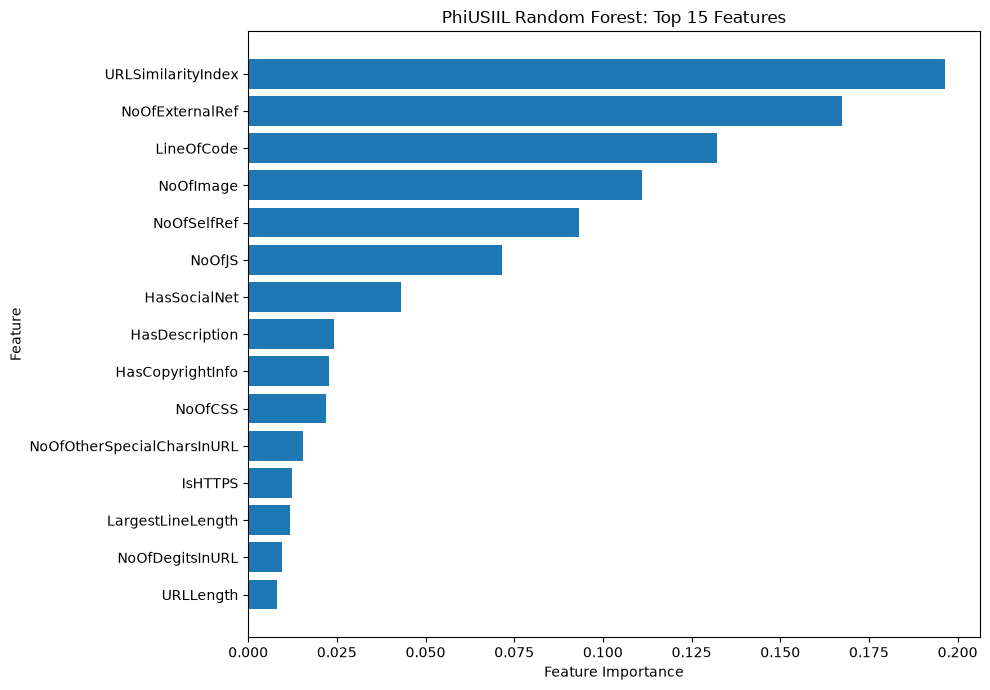

In [12]:
#visualize it
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("PhiUSIIL Random Forest: Top 15 Features")
plt.tight_layout()
plt.show()

In [13]:
#how much the model relies on individual features
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_group,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(permutation_df.head(20))

,feature,importance_mean,importance_std
3,URLSimilarityIndex,2.475557e-01,0.000861
21,IsHTTPS,1.274756e-01,0.000753
22,LineOfCode,1.014675e-04,0.000041
4,CharContinuationRate,2.537105e-05,0.000000
8,NoOfSubDomain,2.537105e-05,0.000000
1,DomainLength,2.537105e-05,0.000000
47,NoOfSelfRef,2.537105e-05,0.000000
26,URLTitleMatchScore,2.537105e-05,0.000000
6,URLCharProb,2.537105e-05,0.000000
13,LetterRatioInURL,1.691403e-05,0.000012


In [14]:
#selecting url only features
url_only_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

available_features = [
    col for col in url_only_features
    if col in X_phi.columns
]

print("URL-only features available:", len(available_features))
print(available_features)

X_url = X_phi[available_features].copy()

print("URL-only feature matrix:", X_url.shape)

URL-only features available: 18
['URLLength', 'DomainLength', 'IsDomainIP', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS']
URL-only feature matrix: (235370, 18)


In [15]:
#training the same unseen-domain split
X_url_train = X_url.iloc[train_idx]
X_url_test = X_url.iloc[test_idx]

url_only_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training URL-only Random Forest...")
url_only_rf.fit(X_url_train, y_train)

url_only_predictions = url_only_rf.predict(X_url_test)

print("URL-only training completed.")

Training URL-only Random Forest...
URL-only training completed.


In [16]:
#comparing url only with the full model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def calculate_metrics(y_true, y_pred, model_name):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "malicious_recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "malicious_f1": f1_score(
            y_true, y_pred, zero_division=0
        ),
        "false_positive_rate": (
            fp / (fp + tn) if fp + tn else 0
        ),
        "false_negative_rate": (
            fn / (fn + tp) if fn + tp else 0
        )
    }

comparison = pd.DataFrame([
    calculate_metrics(
        y_test, predictions, "Full PhiUSIIL features"
    ),
    calculate_metrics(
        y_test, url_only_predictions, "URL-only features"
    )
])

display(comparison.round(6))

,model,accuracy,precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate
0,Full PhiUSIIL features,0.999979,1.000000,0.999949,0.999975,0.000000,0.000051
1,URL-only features,0.997470,0.998271,0.995738,0.997003,0.001263,0.004262


In [17]:
#saving the url only model
import joblib
import json
from pathlib import Path

MODEL_DIR = PROJECT_DIR / "malicious_url" / "models"
RESULTS_DIR = PROJECT_DIR / "malicious_url" / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save URL-only model
model_path = MODEL_DIR / "cyberguard_url_random_forest.pkl"
joblib.dump(url_only_rf, model_path)

# Save exact feature order required at inference time
feature_path = MODEL_DIR / "url_only_features.json"

with open(feature_path, "w", encoding="utf-8") as f:
    json.dump(available_features, f, indent=4)

# Save model comparison
comparison_path = RESULTS_DIR / "url_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)

print("Model saved:", model_path)
print("Feature schema saved:", feature_path)
print("Comparison saved:", comparison_path)

Model saved: C:\Users\HP\OneDrive\Desktop\CyberGuard\malicious_url\models\cyberguard_url_random_forest.pkl
Feature schema saved: C:\Users\HP\OneDrive\Desktop\CyberGuard\malicious_url\models\url_only_features.json
Comparison saved: C:\Users\HP\OneDrive\Desktop\CyberGuard\malicious_url\results\url_model_comparison.csv


In [20]:
#verifying the saved model
loaded_url_model = joblib.load(model_path)

with open(feature_path, "r", encoding="utf-8") as f:
    loaded_features = json.load(f)

test_row = X_url_test.iloc[[0]]

original_prediction = url_only_rf.predict(test_row)
loaded_prediction = loaded_url_model.predict(
    test_row[loaded_features]
)

print("Original prediction:", original_prediction[0])
print("Reloaded prediction:", loaded_prediction[0])

assert original_prediction[0] == loaded_prediction[0]
print("Model reload verification passed.")

Original prediction: 0
Reloaded prediction: 0
Model reload verification passed.


In [22]:
import pandas as pd
from pathlib import Path
import sys

PROJECT_DIR = Path(r"C:\Users\HP\OneDrive\Desktop\BPUT\CYBERGUARD")
SRC_DIR = PROJECT_DIR / "malicious_url" / "src"

sys.path.insert(0, str(SRC_DIR))

from url_features import extract_url_features

sample = phiusiil_clean.sample(
    n=min(10, len(phiusiil_clean)),
    random_state=42
)

comparison_rows = []

for _, row in sample.iterrows():
    extracted = extract_url_features(row["URL"])

    for feature, calculated in extracted.items():
        if feature in sample.columns:
            comparison_rows.append({
                "URL": row["URL"],
                "feature": feature,
                "dataset_value": row[feature],
                "calculated_value": calculated,
                "matches": (
                    abs(float(row[feature]) - float(calculated)) < 1e-6
                    if pd.notna(row[feature])
                    else False
                )
            })

validation_df = pd.DataFrame(comparison_rows)

display(validation_df.head(30))

print(
    "Feature match rate:",
    round(validation_df["matches"].mean() * 100, 2),
    "%"
)

,URL,feature,dataset_value,calculated_value,matches
0,http://www.s107008.hostde20.fornex.host,URLLength,38.000,39.000000,False
1,http://www.s107008.hostde20.fornex.host,DomainLength,32.000,32.000000,True
2,http://www.s107008.hostde20.fornex.host,IsDomainIP,0.000,0.000000,True
3,http://www.s107008.hostde20.fornex.host,TLDLength,4.000,4.000000,True
4,http://www.s107008.hostde20.fornex.host,NoOfSubDomain,3.000,3.000000,True
5,http://www.s107008.hostde20.fornex.host,HasObfuscation,0.000,0.000000,True
6,http://www.s107008.hostde20.fornex.host,NoOfObfuscatedChar,0.000,0.000000,True
7,http://www.s107008.hostde20.fornex.host,ObfuscationRatio,0.000,0.000000,True
8,http://www.s107008.hostde20.fornex.host,NoOfLettersInURL,16.000,24.000000,False
9,http://www.s107008.hostde20.fornex.host,LetterRatioInURL,0.421,0.615385,False


Feature match rate: 71.67 %


In [23]:
feature_summary = (
    validation_df.groupby("feature")
    .agg(
        compared=("matches", "size"),
        matches=("matches", "sum"),
        match_rate=("matches", "mean")
    )
    .sort_values("match_rate")
)

feature_summary["match_rate_percent"] = (
    feature_summary["match_rate"] * 100
).round(2)

display(feature_summary)

,compared,matches,match_rate,match_rate_percent
feature,,,,
LetterRatioInURL,10,0,0.0,0.0
SpacialCharRatioInURL,10,0,0.0,0.0
NoOfOtherSpecialCharsInURL,10,0,0.0,0.0
NoOfLettersInURL,10,0,0.0,0.0
URLLength,10,1,0.1,10.0
DegitRatioInURL,10,8,0.8,80.0
HasObfuscation,10,10,1.0,100.0
IsDomainIP,10,10,1.0,100.0
NoOfDegitsInURL,10,10,1.0,100.0


In [24]:
#inspecting the mismatch
mismatches = validation_df[
    ~validation_df["matches"]
].copy()

display(mismatches.head(30))

,URL,feature,dataset_value,calculated_value,matches
0,http://www.s107008.hostde20.fornex.host,URLLength,38.000,39.000000,False
8,http://www.s107008.hostde20.fornex.host,NoOfLettersInURL,16.000,24.000000,False
9,http://www.s107008.hostde20.fornex.host,LetterRatioInURL,0.421,0.615385,False
11,http://www.s107008.hostde20.fornex.host,DegitRatioInURL,0.211,0.205128,False
15,http://www.s107008.hostde20.fornex.host,NoOfOtherSpecialCharsInURL,3.000,7.000000,False
16,http://www.s107008.hostde20.fornex.host,SpacialCharRatioInURL,0.079,0.179487,False
18,https://www.espresso4you.nl,URLLength,26.000,27.000000,False
26,https://www.espresso4you.nl,NoOfLettersInURL,12.000,21.000000,False
27,https://www.espresso4you.nl,LetterRatioInURL,0.462,0.777778,False
29,https://www.espresso4you.nl,DegitRatioInURL,0.038,0.037037,False


In [25]:
from urllib.parse import urlsplit
import pandas as pd
import re

def inspect_url_counting(url):
    parsed = urlsplit(url)

    variants = {
        "full_url": url,
        "without_scheme": re.sub(r"^https?://", "", url, flags=re.I),
        "without_scheme_www": re.sub(
            r"^https?://(?:www\.)?", "", url, flags=re.I
        ),
        "hostname": parsed.hostname or "",
    }

    results = []

    for name, value in variants.items():
        results.append({
            "variant": name,
            "text": value,
            "length": len(value),
            "letters": sum(c.isalpha() for c in value),
            "digits": sum(c.isdigit() for c in value),
            "special_chars": sum(not c.isalnum() for c in value)
        })

    return pd.DataFrame(results)


sample_url = "http://www.espresso4you.nl"
display(inspect_url_counting(sample_url))

,variant,text,length,letters,digits,special_chars
0,full_url,http://www.espresso4you.nl,26,20,1,5
1,without_scheme,www.espresso4you.nl,19,16,1,2
2,without_scheme_www,espresso4you.nl,15,13,1,1
3,hostname,www.espresso4you.nl,19,16,1,2


In [30]:
url = "https://www.espresso4you.nl"

row = phiusiil_clean.loc[
    phiusiil_clean["URL"] == url
].iloc[0]

print("URL:", url)
print("Dataset URLLength:", row["URLLength"])
print("Dataset NoOfLettersInURL:", row["NoOfLettersInURL"])
print("Dataset LetterRatioInURL:", row["LetterRatioInURL"])
print("Dataset NoOfDegitsInURL:", row["NoOfDegitsInURL"])
print("Dataset DegitRatioInURL:", row["DegitRatioInURL"])
print("Dataset NoOfOtherSpecialCharsInURL:", row["NoOfOtherSpecialCharsInURL"])
print("Dataset SpacialCharRatioInURL:", row["SpacialCharRatioInURL"])

URL: https://www.espresso4you.nl
Dataset URLLength: 26
Dataset NoOfLettersInURL: 12
Dataset LetterRatioInURL: 0.462
Dataset NoOfDegitsInURL: 1
Dataset DegitRatioInURL: 0.038
Dataset NoOfOtherSpecialCharsInURL: 1
Dataset SpacialCharRatioInURL: 0.038


In [29]:
url = "http://www.espresso4you.nl"

matches = phiusiil_clean[
    phiusiil_clean["URL"].astype(str).str.strip() == url
]

if matches.empty:
    print("URL not found. Searching for similar URLs...")
    display(
        phiusiil_clean[
            phiusiil_clean["URL"].astype(str).str.contains(
                "espresso4you.nl",
                case=False,
                na=False,
                regex=False
            )
        ][["URL", "URLLength", "NoOfLettersInURL",
           "LetterRatioInURL", "NoOfDegitsInURL",
           "DegitRatioInURL", "NoOfOtherSpecialCharsInURL",
           "SpacialCharRatioInURL"]].head(10)
    )
else:
    row = matches.iloc[0]

    for feature in [
        "URLLength",
        "NoOfLettersInURL",
        "LetterRatioInURL",
        "NoOfDegitsInURL",
        "DegitRatioInURL",
        "NoOfOtherSpecialCharsInURL",
        "SpacialCharRatioInURL"
    ]:
        print(f"{feature}: {row[feature]}")

URL not found. Searching for similar URLs...


,URL,URLLength,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL
175071,https://www.espresso4you.nl,26,12,0.462,1,0.038,1,0.038


In [31]:
import pandas as pd
from pathlib import Path
import sys

PROJECT_DIR = Path(r"C:\Users\HP\OneDrive\Desktop\CyberGuard")
sys.path.insert(0, str(PROJECT_DIR / "malicious_url" / "src"))

from url_features import extract_url_features

# Find several rows for the same domain
sample = phiusiil_clean[
    phiusiil_clean["URL"].astype(str).str.contains(
        "espresso4you.nl", case=False, na=False, regex=False
    )
].head(10)

features_to_check = [
    "URLLength",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
]

if sample.empty:
    print("No matching URLs found.")
else:
    for _, row in sample.iterrows():
        url = str(row["URL"]).strip()
        extracted = extract_url_features(url)

        print("\nURL:", repr(url))
        print("Python URL length:", len(url))
        print("Dataset URL length:", row["URLLength"])
        print("Python alphabetic characters:", sum(c.isalpha() for c in url))
        print("Python digits:", sum(c.isdigit() for c in url))
        print("Python non-alphanumeric characters:",
              sum(not c.isalnum() for c in url))

        comparison = pd.DataFrame({
            "Dataset": [row[f] for f in features_to_check],
            "Extractor": [extracted[f] for f in features_to_check],
        }, index=features_to_check)

        comparison["Match"] = (
            comparison["Dataset"].astype(float).round(3)
            == comparison["Extractor"].astype(float).round(3)
        )
        display(comparison)


URL: 'https://www.espresso4you.nl'
Python URL length: 27
Dataset URL length: 26
Python alphabetic characters: 21
Python digits: 1
Python non-alphanumeric characters: 5


,Dataset,Extractor,Match
URLLength,26.000,27.000000,False
NoOfLettersInURL,12.000,21.000000,False
LetterRatioInURL,0.462,0.777778,False
NoOfDegitsInURL,1.000,1.000000,True
DegitRatioInURL,0.038,0.037037,False
NoOfOtherSpecialCharsInURL,1.000,5.000000,False
SpacialCharRatioInURL,0.038,0.185185,False


In [32]:
from urllib.parse import urlsplit
import re

url = "https://www.espresso4you.nl"

candidates = {
    "Full URL": url,
    "Without scheme": re.sub(r"^https?://", "", url, flags=re.I),
    "Without scheme and www": re.sub(
        r"^https?://(?:www\.)?", "", url, flags=re.I
    ),
    "Hostname": urlsplit(url).hostname or "",
    "Without www": re.sub(r"^www\.", "", urlsplit(url).hostname or "", flags=re.I),
}

for name, text in candidates.items():
    print(f"\n{name}: {text!r}")
    print("Length:", len(text))
    print("Letters:", sum(c.isalpha() for c in text))
    print("Digits:", sum(c.isdigit() for c in text))
    print("Non-alphanumeric:", sum(not c.isalnum() for c in text))


Full URL: 'https://www.espresso4you.nl'
Length: 27
Letters: 21
Digits: 1
Non-alphanumeric: 5

Without scheme: 'www.espresso4you.nl'
Length: 19
Letters: 16
Digits: 1
Non-alphanumeric: 2

Without scheme and www: 'espresso4you.nl'
Length: 15
Letters: 13
Digits: 1
Non-alphanumeric: 1

Hostname: 'www.espresso4you.nl'
Length: 19
Letters: 16
Digits: 1
Non-alphanumeric: 2

Without www: 'espresso4you.nl'
Length: 15
Letters: 13
Digits: 1
Non-alphanumeric: 1


In [33]:
url = "https://www.espresso4you.nl"

row = phiusiil_clean.loc[
    phiusiil_clean["URL"].astype(str).str.strip().eq(url)
]

if row.empty:
    print("Exact URL not found. Search for the domain:")
    display(
        phiusiil_clean[
            phiusiil_clean["URL"].astype(str).str.contains(
                "espresso4you.nl", case=False, na=False, regex=False
            )
        ][["URL", "URLLength", "NoOfLettersInURL",
           "LetterRatioInURL", "NoOfDegitsInURL",
           "DegitRatioInURL", "NoOfOtherSpecialCharsInURL",
           "SpacialCharRatioInURL"]].head(10)
    )
else:
    display(row[[
        "URL", "URLLength", "NoOfLettersInURL",
        "LetterRatioInURL", "NoOfDegitsInURL",
        "DegitRatioInURL", "NoOfOtherSpecialCharsInURL",
        "SpacialCharRatioInURL"
    ]])

,URL,URLLength,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL
175071,https://www.espresso4you.nl,26,12,0.462,1,0.038,1,0.038


In [34]:
url = "https://www.espresso4you.nl"

row = phiusiil_clean.loc[
    phiusiil_clean["URL"].astype(str).str.strip().eq(url)
].iloc[0]

raw_url = str(row["URL"]).strip()

print("Raw URL:", repr(raw_url))
print("Raw URL length:", len(raw_url))
print("Letters:", sum(c.isalpha() for c in raw_url))
print("Digits:", sum(c.isdigit() for c in raw_url))
print("Non-alphanumeric:", sum(not c.isalnum() for c in raw_url))

print("\nDataset values:")
for feature in [
    "URLLength",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
]:
    print(f"{feature}: {row[feature]}")

Raw URL: 'https://www.espresso4you.nl'
Raw URL length: 27
Letters: 21
Digits: 1
Non-alphanumeric: 5

Dataset values:
URLLength: 26
NoOfLettersInURL: 12
LetterRatioInURL: 0.462
NoOfDegitsInURL: 1
DegitRatioInURL: 0.038
NoOfOtherSpecialCharsInURL: 1
SpacialCharRatioInURL: 0.038


In [35]:
import re
import pandas as pd

def clean_markdown_url(value):
    if pd.isna(value):
        return value

    value = str(value).strip()

    # Convert [display text](target URL) to the target URL
    match = re.fullmatch(r"\[([^\]]+)\]\((https?://[^)]+)\)", value)
    if match:
        return match.group(2)

    return value

phiusiil_clean["URL"] = phiusiil_clean["URL"].apply(clean_markdown_url)

print(repr(phiusiil_clean.loc[
    phiusiil_clean["URL"].astype(str).str.contains(
        "espresso4you.nl", case=False, na=False, regex=False
    ),
    "URL"
].iloc[0]))

'https://www.espresso4you.nl'


In [36]:
url = "https://www.espresso4you.nl"

matches = phiusiil_clean[
    phiusiil_clean["URL"].astype(str).str.strip().eq(url)
]

if matches.empty:
    print("URL not found in cleaned dataset.")
else:
    row = matches.iloc[0]

    print("URL:", repr(row["URL"]))
    print("Dataset URLLength:", row["URLLength"])
    print("Dataset letters:", row["NoOfLettersInURL"])
    print("Dataset digits:", row["NoOfDegitsInURL"])
    print("Dataset special characters:", row["NoOfOtherSpecialCharsInURL"])

    print("\nActual counts from the raw URL:")
    print("Length:", len(url))
    print("Letters:", sum(c.isalpha() for c in url))
    print("Digits:", sum(c.isdigit() for c in url))
    print("Non-alphanumeric:", sum(not c.isalnum() for c in url))

URL: 'https://www.espresso4you.nl'
Dataset URLLength: 26
Dataset letters: 12
Dataset digits: 1
Dataset special characters: 1

Actual counts from the raw URL:
Length: 27
Letters: 21
Digits: 1
Non-alphanumeric: 5


In [38]:
import pandas as pd
from pathlib import Path

csv_path = Path(
    r"C:\Users\HP\OneDrive\Desktop\BPUT\CYBERGUARD"
    r"\malicious_url\data\processed\phiusiil_clean.csv"
)

df_check = pd.read_csv(csv_path)

matches = df_check[
    df_check["URL"].astype(str).str.contains(
        "espresso4you.nl",
        case=False,
        na=False,
        regex=False
    )
]

for _, row in matches.head(5).iterrows():
    print("\nStored URL:", repr(row["URL"]))
    print("Stored length:", row["URLLength"])
    print("Stored letters:", row["NoOfLettersInURL"])
    print("Stored special characters:",
          row["NoOfOtherSpecialCharsInURL"])


Stored URL: 'https://www.espresso4you.nl'
Stored length: 26
Stored letters: 12
Stored special characters: 1


In [40]:
from pathlib import Path
import pandas as pd

raw_path = Path(
    r"C:\Users\HP\OneDrive\Desktop\BPUT\CYBERGUARD"
    r"\malicious_url\data\raw\PhiUSIIL_Phishing_URL_Dataset.csv"
)

raw_df = pd.read_csv(raw_path)

matches = raw_df[
    raw_df["URL"].astype(str).str.contains(
        "espresso4you.nl", case=False, na=False, regex=False
    )
]

display(matches[[
    "URL",
    "URLLength",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL"
]].head())

,URL,URLLength,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL
175298,https://www.espresso4you.nl,26,12,0.462,1,0.038,1,0.038


In [41]:
import re

stored_url = str(raw_df.loc[175298, "URL"])

match = re.fullmatch(
    r"\[([^\]]+)\]\((https?://[^)]+)\)",
    stored_url.strip()
)

if match:
    display_url = match.group(1)
    target_url = match.group(2)

    print("Stored value:", repr(stored_url))
    print("Display URL:", repr(display_url))
    print("Target URL:", repr(target_url))
    print("Display URL length:", len(display_url))
    print("Display URL letters:", sum(c.isalpha() for c in display_url))
    print("Target URL length:", len(target_url))
    print("Target URL letters:", sum(c.isalpha() for c in target_url))
else:
    print("The stored value does not match the expected Markdown-link format.")

The stored value does not match the expected Markdown-link format.


In [42]:
stored_url = str(raw_df.loc[175298, "URL"])

print("Representation:", repr(stored_url))
print("Length:", len(stored_url))
print("First 15 characters:", [repr(c) for c in stored_url[:15]])
print("Last 15 characters:", [repr(c) for c in stored_url[-15:]])
print("Contains '[':", "[" in stored_url)
print("Contains '](':", "](" in stored_url)
print("Contains ']':", "]" in stored_url)
print("Contains '(':", "(" in stored_url)
print("Contains ')':", ")" in stored_url)

Representation: 'https://www.espresso4you.nl'
Length: 27
First 15 characters: ["'h'", "'t'", "'t'", "'p'", "'s'", "':'", "'/'", "'/'", "'w'", "'w'", "'w'", "'.'", "'e'", "'s'", "'p'"]
Last 15 characters: ["'e'", "'s'", "'p'", "'r'", "'e'", "'s'", "'s'", "'o'", "'4'", "'y'", "'o'", "'u'", "'.'", "'n'", "'l'"]
Contains '[': False
Contains '](': False
Contains ']': False
Contains '(': False
Contains ')': False


In [43]:
print("URL column dtype:", raw_df["URL"].dtype)

display(
    raw_df.loc[175295:175300, [
        "URL",
        "URLLength",
        "NoOfLettersInURL",
        "NoOfOtherSpecialCharsInURL"
    ]]
)

URL column dtype: str


,URL,URLLength,NoOfLettersInURL,NoOfOtherSpecialCharsInURL
175295,http://jsacms.in/jvm/iogin-cliente/,35,23,5
175296,https://www.bubakids.com,23,10,1
175297,https://www.tru.ca,17,4,1
175298,https://www.espresso4you.nl,26,12,1
175299,https://www.jewelsofelul.com,27,14,1
175300,https://www.crystalclear3d.com,29,15,1


In [44]:
import numpy as np
import pandas as pd

sample = raw_df.sample(
    n=min(20, len(raw_df)),
    random_state=42
).copy()

sample["URL"] = sample["URL"].astype(str)

sample["actual_length"] = sample["URL"].str.len()
sample["actual_letters"] = sample["URL"].map(
    lambda u: sum(c.isalpha() for c in u)
)
sample["actual_digits"] = sample["URL"].map(
    lambda u: sum(c.isdigit() for c in u)
)
sample["actual_special"] = sample["URL"].map(
    lambda u: sum(not c.isalnum() for c in u)
)

columns = [
    "URL",
    "URLLength", "actual_length",
    "NoOfLettersInURL", "actual_letters",
    "LetterRatioInURL",
    "NoOfDegitsInURL", "actual_digits",
    "NoOfOtherSpecialCharsInURL", "actual_special",
]

display(sample[columns].head(20))

print("\nExact match rates:")
print(
    "URL length:",
    (sample["URLLength"] == sample["actual_length"]).mean()
)
print(
    "Letter count:",
    (sample["NoOfLettersInURL"] == sample["actual_letters"]).mean()
)
print(
    "Digit count:",
    (sample["NoOfDegitsInURL"] == sample["actual_digits"]).mean()
)
print(
    "Special-character count:",
    (sample["NoOfOtherSpecialCharsInURL"] == sample["actual_special"]).mean()
)

,URL,URLLength,actual_length,NoOfLettersInURL,actual_letters,LetterRatioInURL,NoOfDegitsInURL,actual_digits,NoOfOtherSpecialCharsInURL,actual_special
136221,https://www.northcm.ac.th,24,25,10,19,0.417,0,0,2,6
56609,https://unitedmartialartscenters.com/at0/mygov...,59,60,45,51,0.763,1,1,5,8
46393,https://email.mail1.onesignal.os.tc/c/ejwcz02u...,385,385,302,307,0.784,51,51,24,27
129746,http://uqr.to/1il1z,19,19,8,12,0.421,2,2,2,5
131464,https://www.woolworthsrewards.com.au,35,36,21,30,0.600,0,0,2,6
233369,https://www.kubiena-kochblog.com,31,32,17,26,0.548,0,0,2,6
167698,https://couchjumper.com/covantage/index.html,44,44,32,37,0.727,0,0,4,7
157482,http://www.rightnowscope.com,27,28,15,23,0.556,0,0,1,5
64913,http://u1965047.plsk.regruhosting.ru/47/,40,40,19,23,0.475,9,9,5,8
156754,http://www.unblock-me.org,24,25,11,19,0.458,0,0,2,6



Exact match rates:
URL length: 0.3
Letter count: 0.0
Digit count: 1.0
Special-character count: 0.0
